# Decision Tree Classifier | Titanic Survival Prediction

Using identical data as Logistic Regression means every difference in results comes purely from the model, not the data. By the end of this notebook you will have a direct, honest comparison between the two classifiers on every metric.


Logistic Regression draws one straight decision boundary through the feature space and classifies everything on each side. A Decision Tree draws multiple axis-aligned boundaries, partitioning the space into rectangles. It can capture patterns that no straight line could separate.

**What this notebook covers:**
1. Identical preprocessing to M2 for a fair comparison
2. How a Decision Tree Classifier makes decisions (Gini impurity and entropy)
3. Visualizing the actual decision rules
4. Overfitting -- seeing it and fixing it
5. Hyperparameter tuning
6. Feature importance vs Logistic Regression coefficients
7. Full head-to-head comparison with M2


## Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import (
    train_test_split, cross_val_score,
    StratifiedKFold, GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve,
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report
)
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
print("Imports ready")

Imports ready


## 1. Load and Preprocess

Identical to logistic regression so the final comparison is fair.

In [2]:

df = pd.read_csv('../../Datasets/Titanic/Titanic.csv').drop(columns=['Unnamed: 0'])

# --- Missing values ---
df['age'] = df.groupby(['pclass', 'sex'])['age'].transform(
    lambda x: x.fillna(x.median())
)
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df.drop(columns=['deck'], inplace=True)

# --- Drop derived/leakage columns ---
df.drop(columns=['class', 'who', 'adult_male', 'alive', 'alone', 'embark_town'],
        inplace=True, errors='ignore')

# --- Feature engineering (same as M2) ---
df['family_size']     = df['sibsp'] + df['parch'] + 1
df['is_alone']        = (df['family_size'] == 1).astype(int)
df['fare_per_person'] = df['fare'] / df['family_size']
df['is_child']        = (df['age'] < 16).astype(int)
df['age_class']       = df['age'] * df['pclass']

# --- Encoding ---
df['sex_encoded'] = (df['sex'] == 'female').astype(int)
embarked_dummies  = pd.get_dummies(df['embarked'], prefix='embarked',
                                    drop_first=True, dtype=int)
df = pd.concat([df, embarked_dummies], axis=1)
df.drop(columns=['sex', 'embarked'], inplace=True)

feature_cols = [c for c in df.columns if c != 'survived']
X = df[feature_cols]
y = df['survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")
print(f"Features: {len(feature_cols)}")
print(f"Features used: {feature_cols}")
print()
print("Preprocessing identical to M2 -- fair comparison guaranteed")

Train: 712 rows  |  Test: 179 rows
Features: 13
Features used: ['pclass', 'age', 'sibsp', 'parch', 'fare', 'family_size', 'is_alone', 'fare_per_person', 'is_child', 'age_class', 'sex_encoded', 'embarked_Q', 'embarked_S']

Preprocessing identical to M2 -- fair comparison guaranteed


## 2. How a Decision Tree Classifier Makes Decisions

**The core question at every split:**
Which feature and which threshold, if used to split the data here, produces the two purest groups -- groups where one class dominates as much as possible?

**Gini Impurity (default criterion in sklearn):**
```
Gini = 1 - sum(p_i^2)
```
Where p_i is the proportion of class i in the node.

- Gini = 0.0: perfectly pure node -- all samples belong to one class
- Gini = 0.5: maximally impure -- classes are equally mixed (binary case)

**Entropy (alternative criterion):**
```
Entropy = -sum(p_i * log2(p_i))
```
Entropy reaches 0 when a node is pure and log2(n_classes) when completely mixed.
Both criteria produce similar trees in practice. Gini is faster to compute.

**At each leaf node:**
The prediction is the majority class of all training samples that reached that leaf.
The probability output is the fraction of each class in that leaf.

**Example on Titanic:**
If a leaf contains 18 survived and 2 did not survive, the tree predicts:
- Class: survived (majority)
- Probability of survival: 18/20 = 0.90


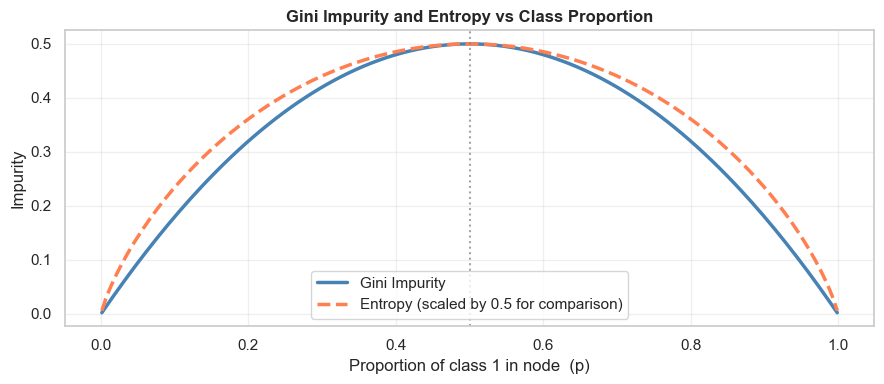

Key values:
  Gini at p=0.5 (maximum impurity): 0.500
  Gini at p=0.0 or p=1.0 (pure):    0.000

The tree always picks the split that maximally reduces Gini impurity
weighted by the number of samples in each resulting child node.


In [3]:
# Visualize Gini impurity
p = np.linspace(0.001, 0.999, 200)
gini    = 1 - (p**2 + (1-p)**2)
entropy = -(p * np.log2(p) + (1-p) * np.log2(1-p))

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p, gini,    color='steelblue', linewidth=2.5, label='Gini Impurity')
ax.plot(p, entropy/2, color='coral', linewidth=2.5, linestyle='--',
        label='Entropy (scaled by 0.5 for comparison)')
ax.axvline(0.5, color='gray', linestyle=':', alpha=0.7)
ax.set_xlabel('Proportion of class 1 in node  (p)')
ax.set_ylabel('Impurity')
ax.set_title('Gini Impurity and Entropy vs Class Proportion', fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Key values:")
print(f"  Gini at p=0.5 (maximum impurity): {1-(0.5**2+0.5**2):.3f}")
print(f"  Gini at p=0.0 or p=1.0 (pure):    0.000")
print()
print("The tree always picks the split that maximally reduces Gini impurity")
print("weighted by the number of samples in each resulting child node.")

## 3. The Overfitting Problem

In [4]:
# Unpruned tree -- no constraints
tree_full = DecisionTreeClassifier(random_state=42)
tree_full.fit(X_train, y_train)

train_acc = accuracy_score(y_train, tree_full.predict(X_train))
test_acc  = accuracy_score(y_test,  tree_full.predict(X_test))

print("=== Unpruned Decision Tree ===")
print(f"Max depth reached: {tree_full.get_depth()}")
print(f"Number of leaves:  {tree_full.get_n_leaves()}")
print(f"Train accuracy:    {train_acc:.4f}")
print(f"Test accuracy:     {test_acc:.4f}")
print(f"Gap:               {train_acc - test_acc:.4f}")
print()
print("Train accuracy is perfect or near-perfect.")
print("The tree has memorized every training passenger.")
print("It has not learned generalizable survival patterns.")

=== Unpruned Decision Tree ===
Max depth reached: 21
Number of leaves:  148
Train accuracy:    0.9831
Test accuracy:     0.7877
Gap:               0.1954

Train accuracy is perfect or near-perfect.
The tree has memorized every training passenger.
It has not learned generalizable survival patterns.


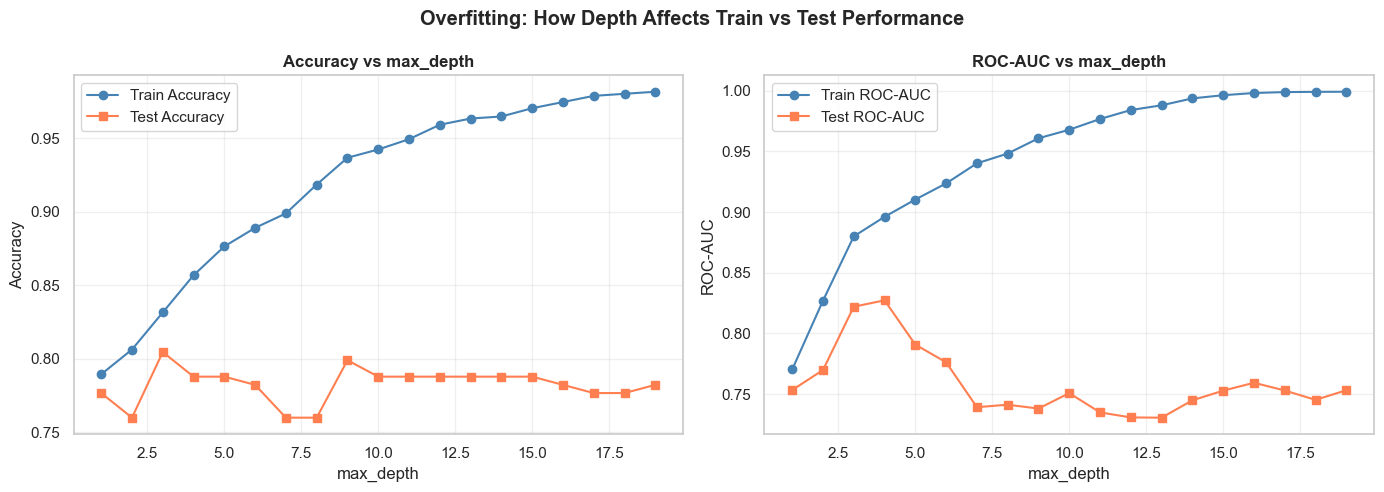

Best depth by test accuracy: 3  (accuracy=0.8045)
Best depth by test ROC-AUC:  4  (AUC=0.8273)


In [5]:
# How depth affects train vs test accuracy
depths = range(1, 20)
train_accs, test_accs = [], []
train_aucs, test_aucs = [], []

for d in depths:
    tree = DecisionTreeClassifier(max_depth=d, random_state=42)
    tree.fit(X_train, y_train)
    train_accs.append(accuracy_score(y_train, tree.predict(X_train)))
    test_accs.append(accuracy_score(y_test,  tree.predict(X_test)))
    train_aucs.append(roc_auc_score(y_train, tree.predict_proba(X_train)[:,1]))
    test_aucs.append(roc_auc_score(y_test,  tree.predict_proba(X_test)[:,1]))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(depths, train_accs, 'o-', color='steelblue', label='Train Accuracy')
axes[0].plot(depths, test_accs,  's-', color='coral',     label='Test Accuracy')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Accuracy vs max_depth', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(depths, train_aucs, 'o-', color='steelblue', label='Train ROC-AUC')
axes[1].plot(depths, test_aucs,  's-', color='coral',     label='Test ROC-AUC')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('ROC-AUC')
axes[1].set_title('ROC-AUC vs max_depth', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Overfitting: How Depth Affects Train vs Test Performance', fontweight='bold')
plt.tight_layout()
plt.show()

best_depth_acc = depths[np.argmax(test_accs)]
best_depth_auc = depths[np.argmax(test_aucs)]
print(f"Best depth by test accuracy: {best_depth_acc}  (accuracy={max(test_accs):.4f})")
print(f"Best depth by test ROC-AUC:  {best_depth_auc}  (AUC={max(test_aucs):.4f})")

## 4. GridSearchCV -- Find the Optimal Tree

In [6]:
param_grid = {
    'max_depth':         [2, 3, 4, 5, 6, 7, 8, None],
    'min_samples_leaf':  [1, 5, 10, 15, 20],
    'min_samples_split': [2, 5, 10, 20],
    'criterion':         ['gini', 'entropy'],
    'max_features':      [None, 'sqrt'],
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

gs = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)
gs.fit(X_train, y_train)

print(f"Best parameters: {gs.best_params_}")
print(f"Best CV ROC-AUC: {gs.best_score_:.4f}")

Best parameters: {'criterion': 'entropy', 'max_depth': 4, 'max_features': None, 'min_samples_leaf': 15, 'min_samples_split': 2}
Best CV ROC-AUC: 0.8696


In [7]:
best_tree = gs.best_estimator_
y_pred = best_tree.predict(X_test)
y_prob = best_tree.predict_proba(X_test)[:, 1]

print("=== Tuned Decision Tree Results ===")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Did Not Survive', 'Survived']))

=== Tuned Decision Tree Results ===
Accuracy:  0.7765
Precision: 0.7042
Recall:    0.7246
F1 Score:  0.7143
ROC-AUC:   0.8008

                 precision    recall  f1-score   support

Did Not Survive       0.82      0.81      0.82       110
       Survived       0.70      0.72      0.71        69

       accuracy                           0.78       179
      macro avg       0.76      0.77      0.77       179
   weighted avg       0.78      0.78      0.78       179



## 5. Visualizing the Decision Rules

This is the unique advantage of Decision Trees. You can read exactly what the model learned.

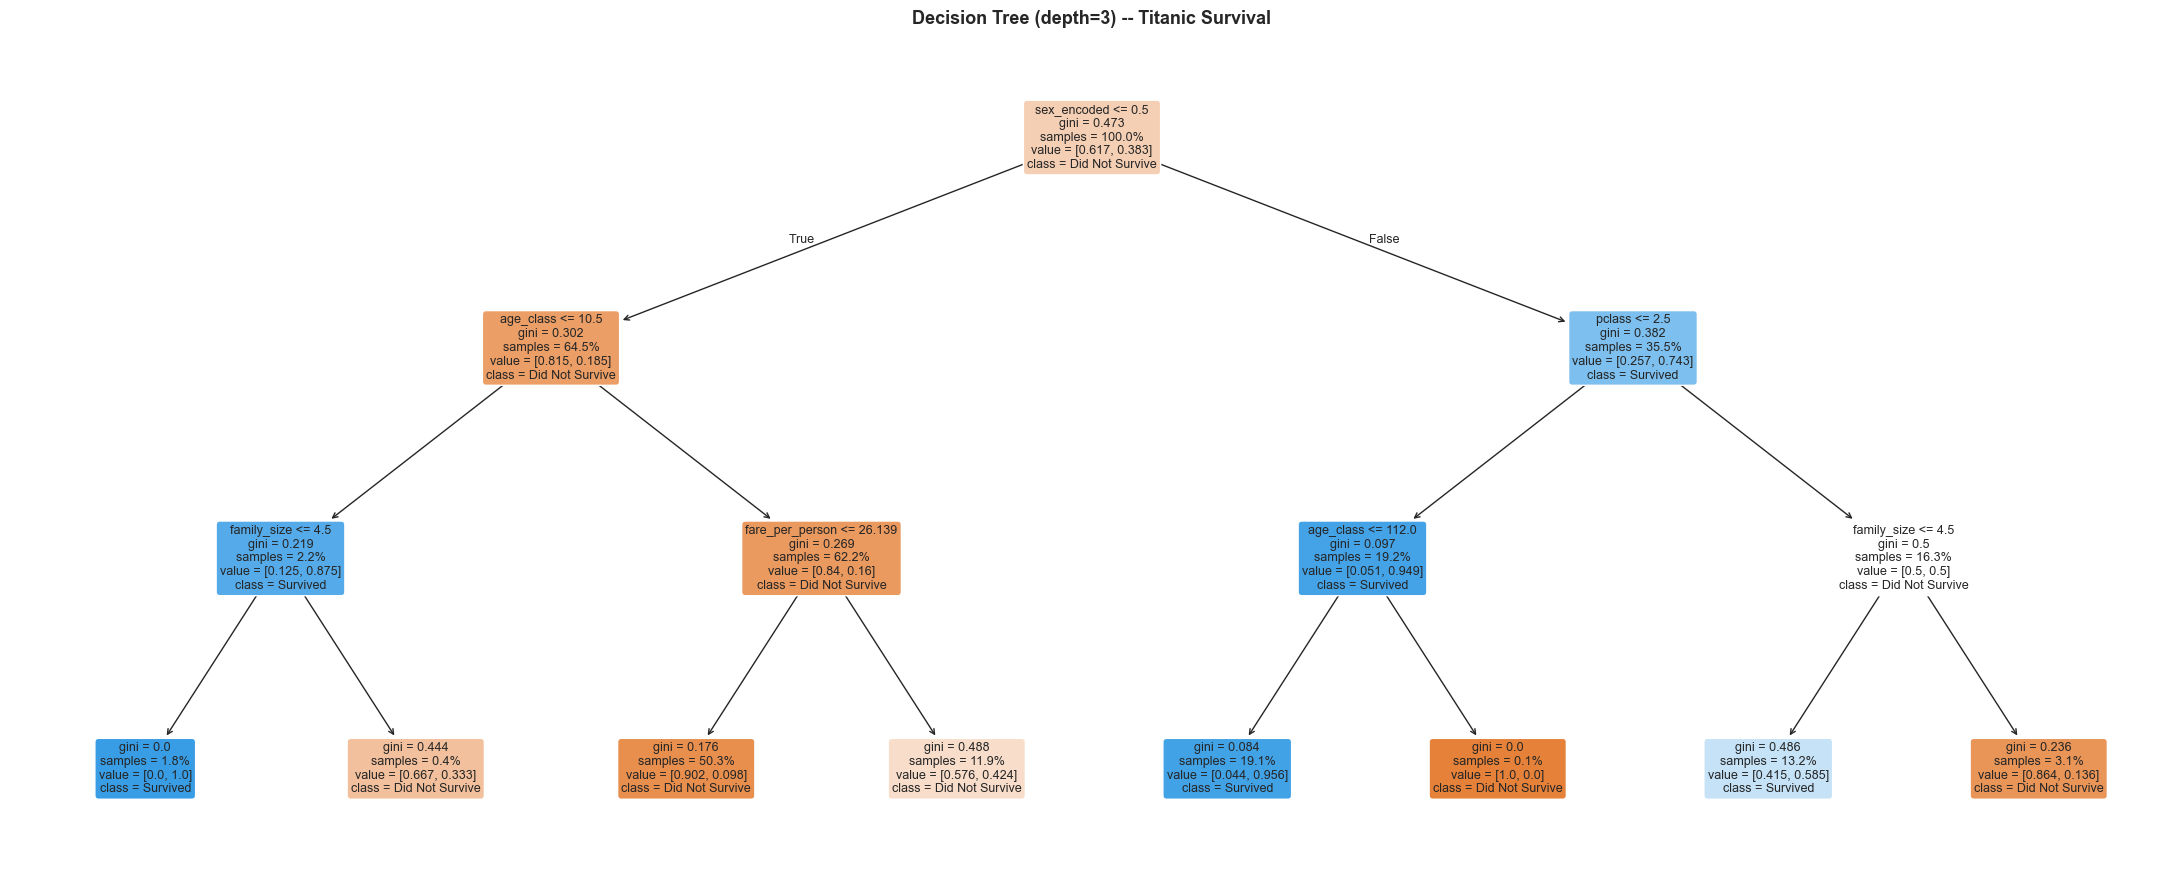

In [8]:
# Use depth-3 for readable visualization
tree_viz = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_viz.fit(X_train, y_train)

plt.figure(figsize=(22, 9))
plot_tree(
    tree_viz,
    feature_names=feature_cols,
    class_names=['Did Not Survive', 'Survived'],
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=True,
    proportion=True
)
plt.title('Decision Tree (depth=3) -- Titanic Survival', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

In [9]:
# Print rules as text -- easier to follow the logic
rules = export_text(tree_viz, feature_names=feature_cols)
print("Decision Rules:")
print(rules)
print()
print("How to read this:")
print("  Each condition is a split on one feature")
print("  'class: Did Not Survive / Survived' = majority class at that leaf")
print("  Trace any passenger from top to bottom to get their prediction")

Decision Rules:
|--- sex_encoded <= 0.50
|   |--- age_class <= 10.50
|   |   |--- family_size <= 4.50
|   |   |   |--- class: 1
|   |   |--- family_size >  4.50
|   |   |   |--- class: 0
|   |--- age_class >  10.50
|   |   |--- fare_per_person <= 26.14
|   |   |   |--- class: 0
|   |   |--- fare_per_person >  26.14
|   |   |   |--- class: 0
|--- sex_encoded >  0.50
|   |--- pclass <= 2.50
|   |   |--- age_class <= 112.00
|   |   |   |--- class: 1
|   |   |--- age_class >  112.00
|   |   |   |--- class: 0
|   |--- pclass >  2.50
|   |   |--- family_size <= 4.50
|   |   |   |--- class: 1
|   |   |--- family_size >  4.50
|   |   |   |--- class: 0


How to read this:
  Each condition is a split on one feature
  'class: Did Not Survive / Survived' = majority class at that leaf
  Trace any passenger from top to bottom to get their prediction


In [10]:
# Walk through a specific passenger manually
print("Manual trace -- Third-class male, age 25, travelling alone:")
print()
print("Start at root node")

sex_enc = 0      # male
pclass  = 3
age     = 25
fam     = 1
is_alone = 1

# Read the actual first split from the tree
feat = tree_viz.tree_.feature[0]
thresh = tree_viz.tree_.threshold[0]
fname = feature_cols[feat]

print(f"  Root split: '{fname} <= {thresh:.3f}'")
print(f"  Our passenger: {fname} = {df[df['sex_encoded']==sex_enc][fname].iloc[0]:.3f}")
print()
print("Follow the path down the tree based on each condition.")
print("The leaf you reach contains the model's prediction and probability.")

Manual trace -- Third-class male, age 25, travelling alone:

Start at root node
  Root split: 'sex_encoded <= 0.500'
  Our passenger: sex_encoded = 0.000

Follow the path down the tree based on each condition.
The leaf you reach contains the model's prediction and probability.


## 6. Confusion Matrix and ROC Curve

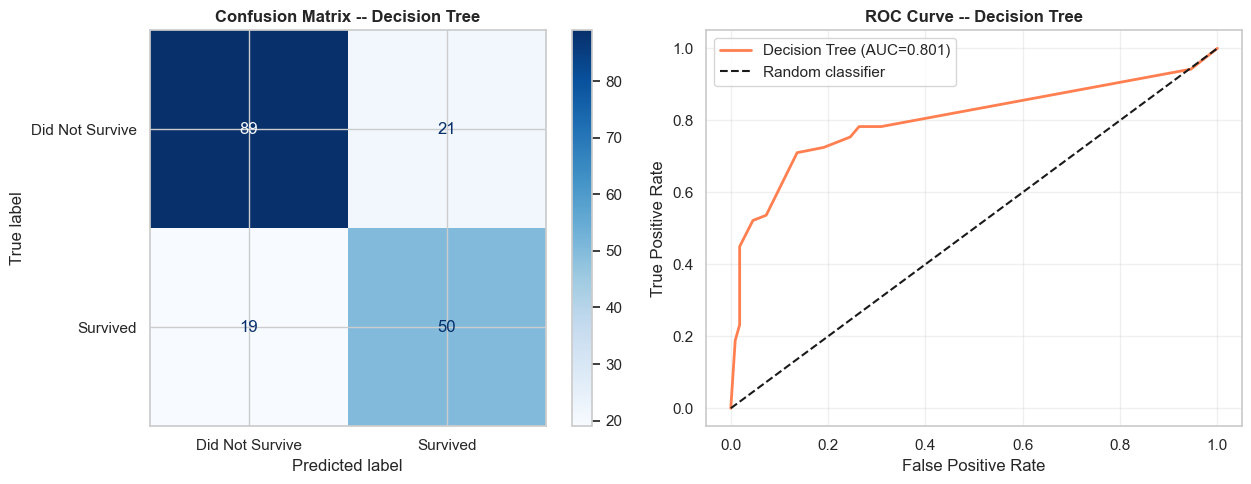

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Confusion Matrix -- Decision Tree', fontweight='bold')

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob)
auc_dt = roc_auc_score(y_test, y_prob)
axes[1].plot(fpr_dt, tpr_dt, color='coral', linewidth=2,
             label=f'Decision Tree (AUC={auc_dt:.3f})')
axes[1].plot([0,1],[0,1],'k--', label='Random classifier')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve -- Decision Tree', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Feature Importance vs logistic regression Coefficients

Two different ways of answering the same question: what mattered most for survival?

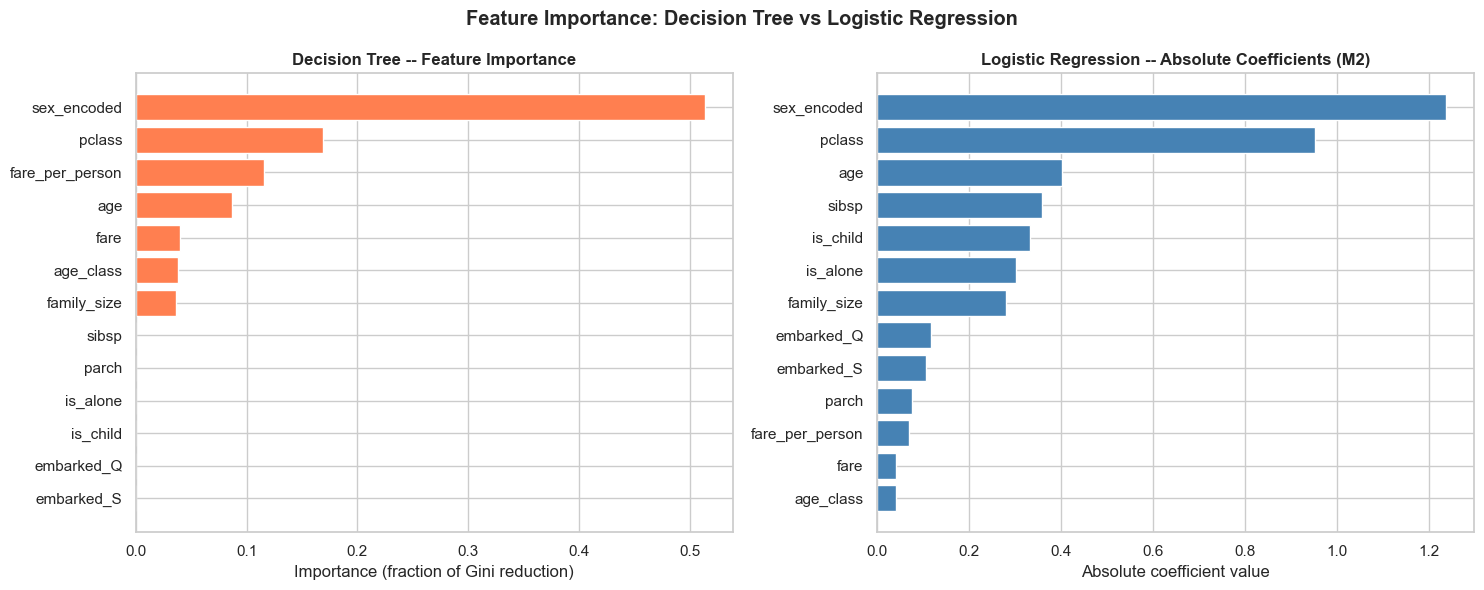

Do both models agree on the most important features?

Decision Tree top 3:
  sex_encoded          importance=0.5133
  pclass               importance=0.1687
  fare_per_person      importance=0.1160

Logistic Regression top 3:
  sex_encoded          |coef|=1.2350
  pclass               |coef|=0.9507
  age                  |coef|=0.4027


In [12]:
importances = best_tree.feature_importances_
feat_imp = pd.DataFrame({
    'feature': feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

# Retrain Logistic Regression with same features for comparison
pipe_lr = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42, max_iter=1000))
])
pipe_lr.fit(X_train, y_train)
lr_coefs = np.abs(pipe_lr.named_steps['model'].coef_[0])
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'abs_coefficient': lr_coefs
}).sort_values('abs_coefficient', ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Decision Tree importance
axes[0].barh(feat_imp['feature'], feat_imp['importance'],
             color='coral', edgecolor='white')
axes[0].set_title('Decision Tree -- Feature Importance', fontweight='bold')
axes[0].set_xlabel('Importance (fraction of Gini reduction)')
axes[0].invert_yaxis()

# Logistic Regression absolute coefficients
axes[1].barh(coef_df['feature'], coef_df['abs_coefficient'],
             color='steelblue', edgecolor='white')
axes[1].set_title('Logistic Regression -- Absolute Coefficients (M2)', fontweight='bold')
axes[1].set_xlabel('Absolute coefficient value')
axes[1].invert_yaxis()

plt.suptitle('Feature Importance: Decision Tree vs Logistic Regression', fontweight='bold')
plt.tight_layout()
plt.show()

print("Do both models agree on the most important features?")
print()
print("Decision Tree top 3:")
for _, row in feat_imp.head(3).iterrows():
    print(f"  {row['feature']:<20} importance={row['importance']:.4f}")
print()
print("Logistic Regression top 3:")
for _, row in coef_df.head(3).iterrows():
    print(f"  {row['feature']:<20} |coef|={row['abs_coefficient']:.4f}")

## 8. Cross-Validation

In [13]:
metrics = {
    'accuracy': cross_val_score(best_tree, X, y, cv=skf, scoring='accuracy'),
    'roc_auc':  cross_val_score(best_tree, X, y, cv=skf, scoring='roc_auc'),
    'f1':       cross_val_score(best_tree, X, y, cv=skf, scoring='f1'),
}

print("5-Fold Stratified Cross-Validation -- Decision Tree:")
print()
print(f"{'Metric':<12} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 65)
for metric, scores in metrics.items():
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{metric:<12} {scores.mean():>8.4f} {scores.std():>8.4f}  {folds}")

5-Fold Stratified Cross-Validation -- Decision Tree:

Metric           Mean      Std  Fold scores
-----------------------------------------------------------------
accuracy       0.8226   0.0205  0.8436  0.8315  0.7865  0.8146  0.8371
roc_auc        0.8610   0.0241  0.8939  0.8592  0.8269  0.8445  0.8807
f1             0.7519   0.0324  0.7812  0.7692  0.6935  0.7402  0.7752


## 9. Head-to-Head: Decision Tree vs Logistic Regression (M2)

In [14]:
# Logistic Regression metrics on same test set
lr_pred = pipe_lr.predict(X_test)
lr_prob = pipe_lr.predict_proba(X_test)[:,1]

results = {
    'Logistic Regression (M2)': {
        'accuracy':  accuracy_score(y_test, lr_pred),
        'precision': precision_score(y_test, lr_pred),
        'recall':    recall_score(y_test, lr_pred),
        'f1':        f1_score(y_test, lr_pred),
        'roc_auc':   roc_auc_score(y_test, lr_prob),
        'pred': lr_pred, 'prob': lr_prob
    },
    'Decision Tree (M4)': {
        'accuracy':  accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall':    recall_score(y_test, y_pred),
        'f1':        f1_score(y_test, y_pred),
        'roc_auc':   roc_auc_score(y_test, y_prob),
        'pred': y_pred, 'prob': y_prob
    }
}

print("=" * 65)
print("  M2 Logistic Regression vs M4 Decision Tree -- Titanic")
print("=" * 65)
print(f"{'Metric':<12}", end="")
for model in results:
    print(f"  {model:>28}", end="")
print()
print("-" * 65)

for metric in ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']:
    print(f"{metric:<12}", end="")
    vals = [results[m][metric] for m in results]
    best = max(vals)
    for model, val in zip(results, vals):
        flag = " *" if val == best else "  "
        print(f"  {val:>27.4f}{flag}", end="")
    print()

print()
print("* = better score on that metric")

  M2 Logistic Regression vs M4 Decision Tree -- Titanic
Metric            Logistic Regression (M2)            Decision Tree (M4)
-----------------------------------------------------------------
accuracy                           0.8268 *                       0.7765  
precision                          0.8276 *                       0.7042  
recall                             0.6957                         0.7246 *
f1                                 0.7559 *                       0.7143  
roc_auc                            0.8589 *                       0.8008  

* = better score on that metric


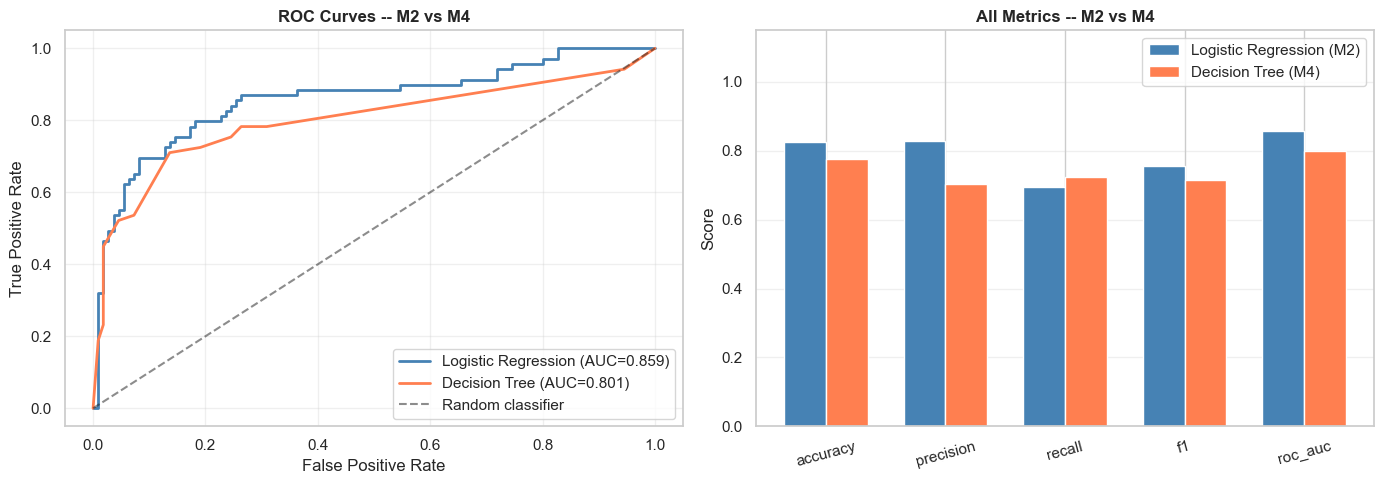

In [15]:
# ROC curves overlaid
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ROC curves
fpr_lr, tpr_lr, _ = roc_curve(y_test, lr_prob)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob)
auc_lr = roc_auc_score(y_test, lr_prob)
auc_dt = roc_auc_score(y_test, y_prob)

axes[0].plot(fpr_lr, tpr_lr, color='steelblue', linewidth=2,
             label=f'Logistic Regression (AUC={auc_lr:.3f})')
axes[0].plot(fpr_dt, tpr_dt, color='coral', linewidth=2,
             label=f'Decision Tree (AUC={auc_dt:.3f})')
axes[0].plot([0,1],[0,1],'k--', alpha=0.5, label='Random classifier')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves -- M2 vs M4', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Metric bar chart
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']
lr_vals = [results['Logistic Regression (M2)'][m] for m in metrics_list]
dt_vals = [results['Decision Tree (M4)'][m] for m in metrics_list]

x = np.arange(len(metrics_list))
width = 0.35
axes[1].bar(x - width/2, lr_vals, width, label='Logistic Regression (M2)',
             color='steelblue', edgecolor='white')
axes[1].bar(x + width/2, dt_vals, width, label='Decision Tree (M4)',
             color='coral', edgecolor='white')
axes[1].set_xticks(x)
axes[1].set_xticklabels(metrics_list, rotation=15)
axes[1].set_ylabel('Score')
axes[1].set_title('All Metrics -- M2 vs M4', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 1.15)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

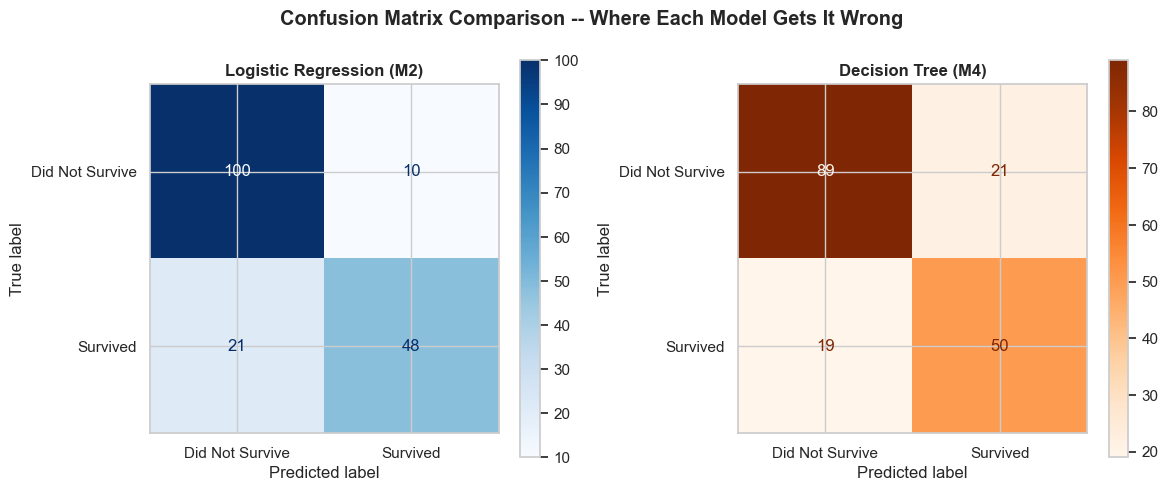

Look at false negatives (survivors predicted as dead) and
false positives (non-survivors predicted as alive).
Which model makes fewer of each? Does one model systematically
misclassify a particular group the other gets right?


In [16]:
# Confusion matrix comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test, lr_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Blues', ax=axes[0]
)
axes[0].set_title('Logistic Regression (M2)', fontweight='bold')

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Did Not Survive', 'Survived'],
    cmap='Oranges', ax=axes[1]
)
axes[1].set_title('Decision Tree (M4)', fontweight='bold')

plt.suptitle('Confusion Matrix Comparison -- Where Each Model Gets It Wrong',
             fontweight='bold')
plt.tight_layout()
plt.show()

print("Look at false negatives (survivors predicted as dead) and")
print("false positives (non-survivors predicted as alive).")
print("Which model makes fewer of each? Does one model systematically")
print("misclassify a particular group the other gets right?")

## Summary

**What the comparison tells you:**
On a dataset like Titanic -- moderate size, mix of numeric and categorical features, strong linear patterns (sex and class dominate) -- Logistic Regression and a well-tuned Decision Tree tend to perform similarly. Neither dominates convincingly. This is expected.

**When Decision Tree genuinely beats Logistic Regression:**
- The decision boundary is non-linear and cannot be approximated by a weighted sum
- There are strong threshold effects (e.g. age < 15 behaves completely differently than age >= 15)
- Features interact in complex ways that are hard to engineer manually

**When Logistic Regression beats Decision Tree:**
- The underlying relationship is approximately linear in log-odds
- The dataset is small -- trees overfit more easily
- You need well-calibrated probabilities -- tree leaf probabilities can be coarse

**The interpretability difference:**
Both models are interpretable, but in different ways. Logistic Regression gives you a continuous coefficient per feature. Decision Tree gives you a set of explicit if-then rules. For the Titanic problem, the tree rule "if female and first/second class then predict survived" is immediately readable. The logistic regression equivalent requires computing odds ratios to reach the same conclusion.

